# Linear Regression via Gradient Descent — From Scratch

Predicts bone mineral density (`bmd`) using batch gradient descent implemented from scratch
(no `sklearn.linear_model`), tracking how each weight evolves over training and evaluating with
MSE, RMSE, and MAE.



In [10]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [11]:
!git clone https://github.com/armitakamari/ML-Fundamentals-Implementations.git
%cd ML-Fundamentals-Implementations

Cloning into 'ML-Fundamentals-Implementations'...
remote: Enumerating objects: 44, done.
remote: Counting objects: 100% (44/44), done.
remote: Compressing objects: 100% (42/42), done.
remote: Total 44 (delta 16), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (44/44), 182.06 KiB | 2.39 MiB/s, done.
Resolving deltas: 100% (16/16), done.
/content/ML-Fundamentals-Implementations/ML-Fundamentals-Implementations


## Load & Prepare Data

In [12]:
data = pd.read_csv("./data/bmd.csv", sep=",", engine="python")
data.drop("id", axis=1, inplace=True)

data = pd.get_dummies(data, drop_first=True)
data = data.ffill().bfill()

In [13]:
X = data.drop("bmd", axis=1)
y = data["bmd"]

feature_names = ["bias"] + list(X.columns)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Gradient Descent

In [14]:
X_train_b = np.c_[np.ones((X_train.shape[0], 1)), X_train]
X_test_b = np.c_[np.ones((X_test.shape[0], 1)), X_test]

learning_rate = 0.003
n_iterations = 1000
n_features = X_train_b.shape[1]
weights = np.zeros(n_features)
weights_history = []

In [15]:
for i in range(n_iterations):
    gradients = 2 / X_train_b.shape[0] * X_train_b.T.dot(X_train_b.dot(weights) - y_train)
    weights -= learning_rate * gradients
    weights_history.append(weights.copy())

weights_history = np.array(weights_history)

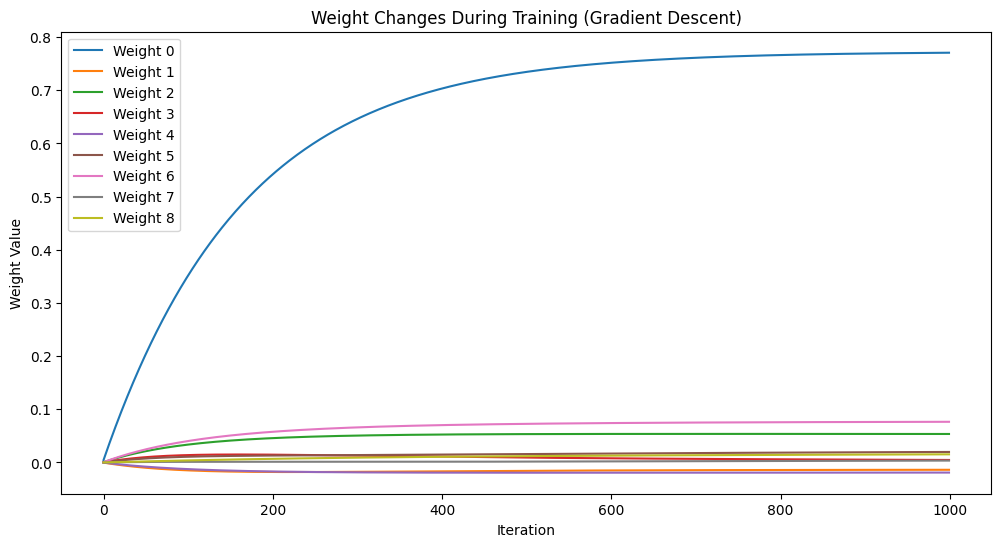

In [16]:
plt.figure(figsize=(12, 6))
for i in range(n_features):
    plt.plot(weights_history[:, i], label=f"Weight {i}")
plt.xlabel("Iteration")
plt.ylabel("Weight Value")
plt.title("Weight Changes During Training (Gradient Descent)")
plt.legend()
plt.show()

## Evaluation

In [17]:
y_pred = X_test_b.dot(weights)

mse = np.mean((y_test - y_pred) ** 2)
rmse = np.sqrt(mse)
mae = np.mean(np.abs(y_test - y_pred))

print("MSE:", mse)
print("RMSE:", rmse)
print("MAE:", mae)

MSE: 0.009845561410421323
RMSE: 0.09922480239547632
MAE: 0.07908211968490812


In [18]:
weights_df = pd.DataFrame({"Feature": feature_names, "Weight": weights})
print("\nFinal Feature Weights:")
print(weights_df)


Final Feature Weights:
                      Feature    Weight
0                        bias  0.770647
1                         age -0.013761
2                   weight_kg  0.053590
3                   height_cm  0.004728
4                waiting_time -0.018997
5                       sex_M  0.019784
6        fracture_no fracture  0.076501
7  medication_Glucocorticoids  0.003531
8    medication_No medication  0.015329
